In [1]:
import json
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

SEED = 42                      # reproductibilité : mêmes résultats à chaque exécution
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})
print("Imports OK")

Imports OK


### Étape 1 — Simulation des données capteurs

On imagine l'ESP8266 qui envoie **1 mesure par minute** (dans le vrai projet ce sera plutôt toutes les 2 à 10 secondes ; le DHT22 ne peut pas être lu plus vite qu'environ toutes les 2 s).

**Capteurs simulés :**
- `temperature` (°C) et `humidity` (%) — DHT22 : cycle jour/nuit + bruit ;
- `gas` — MQ-2, valeur brute du convertisseur analogique (0–1023) ;
- `pir` — détecteur de présence (0/1), généré mais **non utilisé** par ce modèle (il servira plutôt à la partie vision / corrélation).

**Pannes injectées (uniquement dans la période de test) :**

| Événement | Description | Pourquoi c'est intéressant |
|---|---|---|
| `derive_lente` | Température et gaz montent **lentement et ensemble** | C'est l'exemple du sujet : prédire l'incident *avant* le seuil critique |
| `pic_gaz` | Pic brutal de gaz puis retombée | Fuite de gaz |
| `surchauffe` | Montée rapide de la température | Surchauffe thermique |
| `capteur_fige` | Le DHT22 renvoie toujours la même valeur | Panne de capteur : aucune valeur n'est « trop haute », un `if` ne la voit pas ! |

In [ ]:
# Simulateur de données normales

def simulate_normal(n_days, seed, start="2026-10-05 08:00"):
    """Simule le fonctionnement NORMAL des capteurs (1 mesure / minute)."""
    rng = np.random.default_rng(seed)
    n = n_days * 24 * 60
    idx = pd.date_range(start, periods=n, freq="1min", name="timestamp")
    hours = idx.hour + idx.minute / 60

    # Température : 22 °C en moyenne, +/- 4 °C selon l'heure, bruit lissé (inertie du capteur)
    temp = 22 + 4 * np.sin(2 * np.pi * (hours - 9) / 24)
    temp = temp + pd.Series(rng.normal(0, 0.35, n)).ewm(span=3).mean().to_numpy()

    # Humidité : anti-corrélée à la température
    hum = 55 - 1.2 * (temp - 22) + rng.normal(0, 1.5, n)

    # Gaz MQ-2 : valeur de repos ~180 (sur 1023), très légère variation journalière
    gas = 180 + 8 * np.sin(2 * np.pi * (hours - 14) / 24) + rng.normal(0, 5, n)

    # Présence PIR : déclenchements aléatoires rares
    pir = (rng.random(n) < 0.02).astype(int)

    df = pd.DataFrame({"temperature": temp, "humidity": hum, "gas": gas, "pir": pir}, index=idx)
    df["label"] = 0          # 0 = normal, 1 = anomalie  (sert UNIQUEMENT à évaluer)
    df["event"] = "normal"
    return df

# Injecte une panne dans df, à partir de la ligne `start_min`, pendant `dur_min` minutes.
def inject_event(df, kind, start_min, dur_min):
    df = df.copy()
    s, e = start_min, start_min + dur_min
    k = np.arange(dur_min)
    r = k / dur_min                                   # progression 0 -> 1
    temp, hum, gas = (df[c].to_numpy(copy=True) for c in ("temperature", "humidity", "gas"))

    if kind == "derive_lente":
        d_temp = 20 * r ** 1.5                        # démarre doucement, accélère
        temp[s:e] += d_temp
        gas[s:e] += 160 * r ** 1.5
        hum[s:e] -= 0.5 * d_temp
    elif kind == "pic_gaz":
        profil = np.minimum(k / 3, 1) * np.exp(-k / (dur_min / 2))
        gas[s:e] += 260 * profil
    elif kind == "surchauffe":
        d_temp = 12 * np.minimum(k / (dur_min * 0.5), 1)
        temp[s:e] += d_temp
        hum[s:e] -= 0.8 * d_temp
    elif kind == "capteur_fige":
        temp[s:e] = temp[s]                           # le DHT22 « gèle »
        hum[s:e] = hum[s]
    else:
        raise ValueError(kind)

    df["temperature"], df["humidity"], df["gas"] = temp, hum, np.clip(gas, 0, 1023)
    df.iloc[s:e, df.columns.get_loc("label")] = 1
    df.iloc[s:e, df.columns.get_loc("event")] = kind
    return df

In [ ]:
# Génération des données
N_TRAIN_DAYS, N_TEST_DAYS = 4, 2
DAY = 24 * 60

data = simulate_normal(N_TRAIN_DAYS + N_TEST_DAYS, seed=SEED)
t0 = N_TRAIN_DAYS * DAY                               # début de la période de test (minutes)

# (type, minute de début dans la période de test, durée en minutes)
TEST_EVENTS = [
    ("derive_lente", 300, 240),
    ("pic_gaz",      900,  15),
    ("capteur_fige", 1300, 60),
    ("surchauffe",   1800, 40),
    ("derive_lente", 2300, 200),
]
for kind, start, dur in TEST_EVENTS:
    data = inject_event(data, kind, t0 + start, dur)

train = data.iloc[:t0]          # 4 jours de fonctionnement NORMAL
test  = data.iloc[t0:]          # 2 jours avec des pannes

print(f"Train : {len(train)} mesures | anomalies : {train['label'].sum()}")
print(f"Test  : {len(test)} mesures | anomalies : {test['label'].sum()} ({test['label'].mean():.1%})")
data.head()

Train : 5760 mesures | anomalies : 0
Test  : 2880 mesures | anomalies : 555 (19.3%)


,temperature,humidity,gas,pir,label,event
timestamp,,,,,,
2026-10-05 08:00:00,21.071375,57.434811,183.447686,0,0,normal
2026-10-05 08:01:00,20.774480,59.068109,167.283575,0,0,normal
2026-10-05 08:02:00,21.059808,55.252526,164.955066,0,0,normal
2026-10-05 08:03:00,21.219578,53.183658,180.442210,0,0,normal
2026-10-05 08:04:00,20.778670,57.214576,178.607496,0,0,normal


> ⚠️ **Point méthodologique important — découpe temporelle**
> Sur une série temporelle, on **ne mélange jamais** les lignes (`shuffle`) : on entraîne sur le passé et on teste sur le futur, comme en conditions réelles.
> Ici le modèle sera entraîné sur 4 jours **sans panne** (la « période de calibration » où le boîtier fonctionne normalement) — c'est exactement ce que tu pourras faire avec la vraie ESP8266 : laisser tourner le boîtier quelques heures au calme, puis s'en servir comme référence du « normal ».

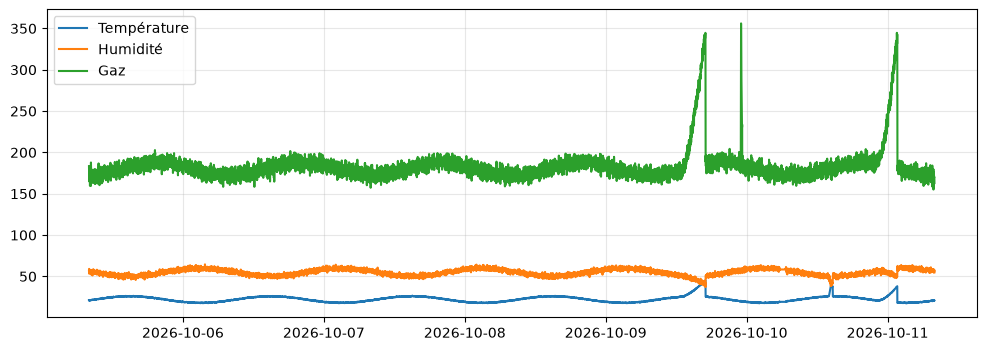

In [7]:
# Exploration visuelle des données
plt.figure(figsize=(12, 4))
plt.plot(data["temperature"], label="Température")
plt.plot(data["humidity"], label="Humidité")
plt.plot(data["gas"], label="Gaz")
plt.legend()
plt.show()

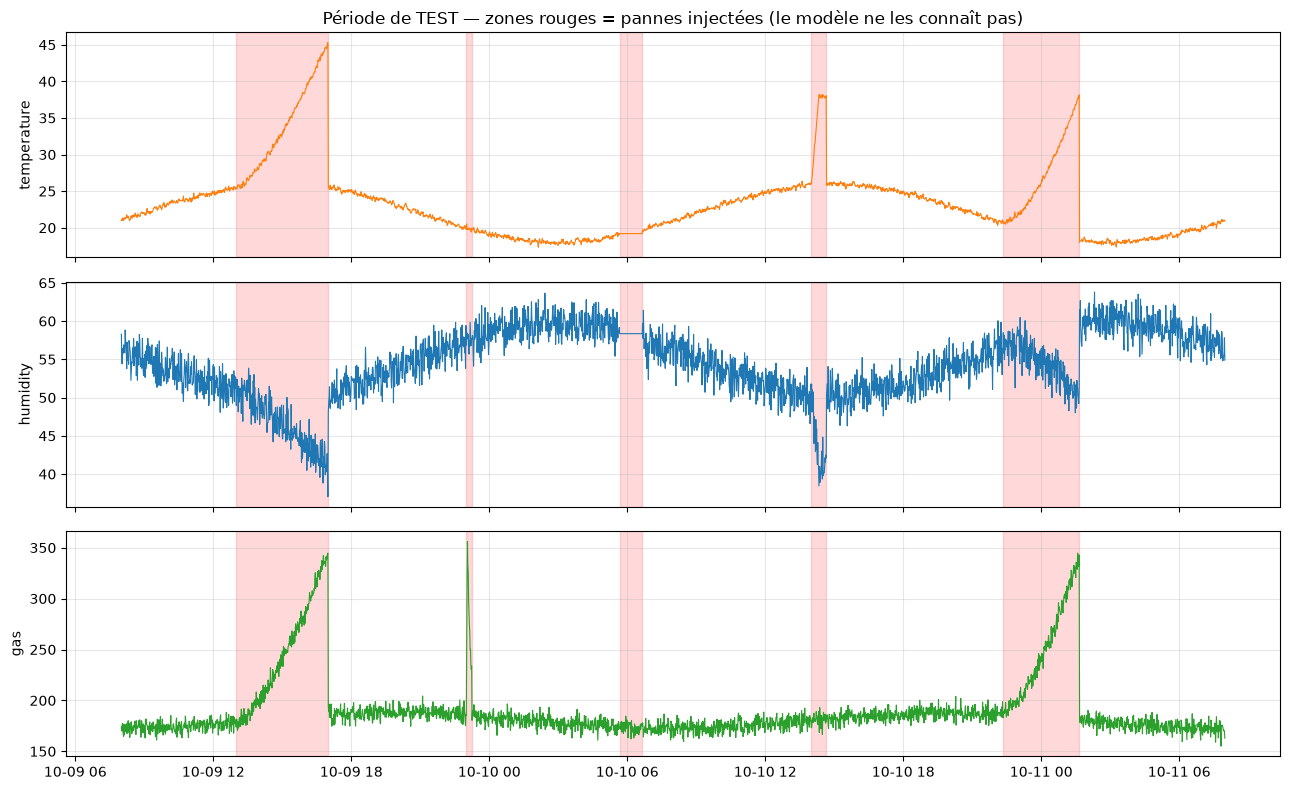

In [8]:
def shade_events(ax, df):
    """Colorie en rouge les périodes d'anomalie réelles (vérité terrain)."""
    run = (df["label"] != df["label"].shift()).cumsum()
    for _, g in df[df["label"] == 1].groupby(run[df["label"] == 1]):
        ax.axvspan(g.index[0], g.index[-1], color="red", alpha=0.15)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, col, color in zip(axes, ["temperature", "humidity", "gas"], ["tab:orange", "tab:blue", "tab:green"]):
    ax.plot(test.index, test[col], color=color, lw=0.8)
    shade_events(ax, test)
    ax.set_ylabel(col)
axes[0].set_title("Période de TEST — zones rouges = pannes injectées (le modèle ne les connaît pas)")
plt.tight_layout(); plt.show()

**Observations :**
- La **dérive lente** (1er et 5e événement) est quasiment invisible au début : température et gaz restent dans les valeurs « normales » pendant un long moment. Un seuil fixe ne réagit qu'à la fin, quand c'est presque trop tard.
- Le **capteur figé** ne dépasse aucune valeur limite : la température reste plausible, c'est son **absence de variation** qui est anormale.
- Le **pic de gaz** et la **surchauffe** sont plus évidents.

Il faut donc regarder **la dynamique** (pente, variabilité, corrélation) et pas seulement la valeur instantanée. C'est le rôle du feature engineering.

### Étape 3 — Feature engineering (créer des variables « cinétiques »)

Un modèle ne comprend pas le « temps » : on lui donne une **photo à l'instant t**. Pour qu'il perçoive la dynamique, on résume la fenêtre récente de chaque capteur :

| Feature | Formule | Ce qu'elle détecte |
|---|---|---|
| `temperature`, `humidity`, `gas` | valeur brute | Valeurs hors plage |
| `temp_pente`, `gas_pente` | (x(t) − x(t−30)) / 30 | **Dérive lente** (montée régulière) |
| `temp_std`, `hum_std`, `gas_std` | écart-type sur 15 min (en échelle log pour T° et humidité) | **Capteur figé** (variabilité ≈ 0) ou instable |
| `temp_amp`, `hum_amp`, `gas_amp` | max − min sur 15 min (en échelle log) | Même idée, vue complémentaire : une amplitude nulle = signal plat |
| `corr_temp_gas` | corrélation T°/gaz sur 30 min | **Les deux montent ensemble** (exemple du sujet) |

In [9]:
# Feature engineering

# Fenêtres de temps
W = 15            # petite fenêtre (en nb de mesures = minutes ici)
W_LONG = 2 * W    # grande fenêtre

# Crée des features à partir des mesures brutes
def make_features(df, w=W, w_long=W_LONG):
    """Transforme les mesures brutes en variables décrivant la dynamique récente."""
    f = pd.DataFrame(index=df.index)
    f["temperature"] = df["temperature"]
    f["humidity"]    = df["humidity"]
    f["gas"]         = df["gas"]

    # Pentes (variation par minute sur la grande fenêtre)
    f["temp_pente"] = (df["temperature"] - df["temperature"].shift(w_long)) / w_long
    f["gas_pente"]  = (df["gas"] - df["gas"].shift(w_long)) / w_long

    # Variabilité récente. Échelle log10 : un capteur figé (variabilité = 0) devient
    # alors une valeur TRÈS éloignée du normal (le +1e-3 évite log(0))
    lg = lambda x: np.log10(x + 1e-3)
    f["temp_std"] = lg(df["temperature"].rolling(w).std())
    f["hum_std"]  = lg(df["humidity"].rolling(w).std())
    f["gas_std"]  = df["gas"].rolling(w).std()

    # Amplitude (max - min) sur la petite fenêtre : renforce la détection des signaux « plats »
    f["temp_amp"] = lg(df["temperature"].rolling(w).max() - df["temperature"].rolling(w).min())
    f["hum_amp"]  = lg(df["humidity"].rolling(w).max() - df["humidity"].rolling(w).min())
    f["gas_amp"]  = lg(df["gas"].rolling(w).max() - df["gas"].rolling(w).min())

    # Corrélation glissante température / gaz.
    # Piège : si un capteur est figé, la corrélation vaut NaN -> on la remplace par 0
    f["corr_temp_gas"] = df["temperature"].rolling(w_long).corr(df["gas"]).fillna(0)

    # Les premières lignes n'ont pas assez d'historique -> NaN -> on les retire
    return f.dropna()

X_train = make_features(train)
X_test  = make_features(test)
y_test  = test.loc[X_test.index, "label"]

print("X_train :", X_train.shape, "| X_test :", X_test.shape)
X_train.describe().T[["mean", "std", "min", "max"]].round(3)

X_train : (5730, 12) | X_test : (2850, 12)


,mean,std,min,max
temperature,21.999,2.833,17.523,26.717
humidity,54.971,3.727,45.685,64.579
gas,180.178,7.491,157.235,202.815
temp_pente,-0.000,0.016,-0.050,0.052
gas_pente,-0.000,0.239,-0.884,0.902
temp_std,-0.723,0.103,-1.182,-0.421
hum_std,0.170,0.087,-0.163,0.418
gas_std,4.908,0.914,2.270,8.397
temp_amp,-0.187,0.106,-0.655,0.110
hum_amp,0.719,0.096,0.326,0.941


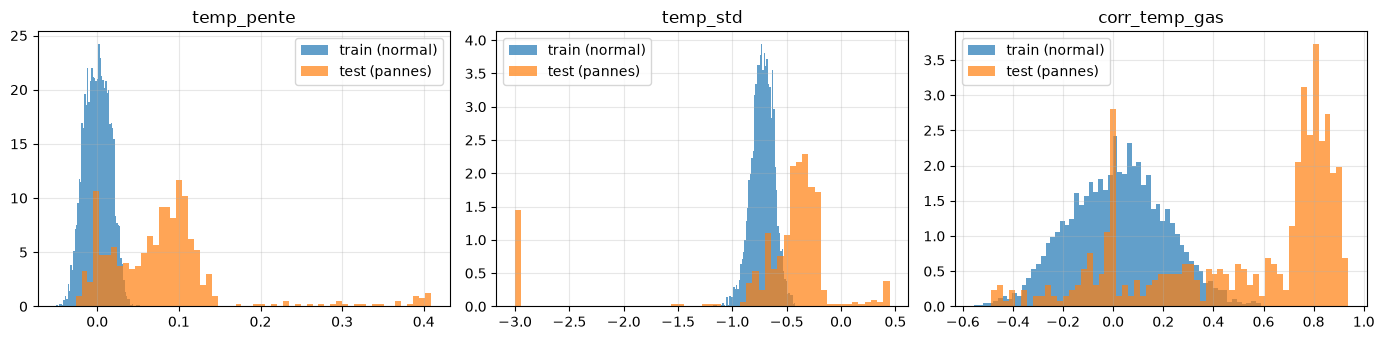

In [10]:
# Comparons une feature en période normale vs pendant les pannes
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["temp_pente", "temp_std", "corr_temp_gas"]):
    ax.hist(X_train[col], bins=60, alpha=0.7, label="train (normal)", density=True)
    ax.hist(X_test.loc[y_test == 1, col], bins=60, alpha=0.7, label="test (pannes)", density=True)
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

>**Leçon apprise en construisant ce notebook** : avec seulement `temp_std` et `hum_std`, l'Isolation Forest *ratait* le capteur figé (2 features anormales noyées parmi 9). Passer en échelle log et ajouter les amplitudes a rendu cette panne détectable. Le choix des features compte souvent plus que le choix du modèle.

On voit que les pannes occupent des zones **que le modèle n'a jamais rencontrées** à l'entraînement (pente plus forte, écart-type nul, corrélation proche de 1…). C'est exactement ce que va exploiter l'Isolation Forest.

## Étape 4 — Entraînement de l'Isolation Forest

**Principe (à savoir expliquer au jury !)** : l'algorithme construit des arbres de décision **aléatoires** qui découpent l'espace. Un point **rare / atypique** est isolé en peu de découpes (chemin court) ; un point **normal** noyé dans la masse demande beaucoup de découpes (chemin long). Le **score d'anomalie** est lié à cette longueur de chemin.

**Avantages pour Sentinel-X :**
- **Non supervisé** : on n'a besoin d'aucun exemple de panne pour l'entraîner (on n'en aura pas ou très peu en vrai) ;
- Pas besoin de normaliser les données (basé sur des arbres) ;
- Rapide : OK pour tourner sur un Raspberry Pi 5.

**Hyperparamètres principaux :** `n_estimators` (nombre d'arbres), `contamination` (proportion attendue d'anomalies ; on laisse `"auto"` et on choisira le seuil nous-mêmes à l'étape suivante).

In [11]:
# Entrainement
iso = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=SEED,
    n_jobs=-1,
)
iso.fit(X_train)       # entraînement sur le NORMAL uniquement
print("Modèle entraîné ✅")

Modèle entraîné ✅


In [ ]:
# Entraînement du modèle Isolation Forest

# Entraîne un Isolation Forest sur les données normales
clf = IsolationForest(n_estimators=100, max_samples="auto", contamination=0.01, random_state=SEED)
clf.fit(X_train)

# Prédit les anomalies
y_pred = clf.predict(X_test)

## Étape 5 — Score, seuil et règle de persistance

`decision_function` renvoie un score : **plus il est négatif, plus le point est anormal**.

On ne se contente pas de la décision par défaut du modèle. On construit notre propre règle en deux temps :

1. **Seuil appris sur les données normales** : on prend un percentile très bas des scores observés à l'entraînement (ici le 0,5 %). Ça revient à dire : *« en fonctionnement normal, on tolère ~0,5 % de points qui ressemblent à des anomalies »*.
2. **Persistance** : on ne déclenche l'alerte que si **3 mesures consécutives** sont sous le seuil. Ça évite les fausses alertes dues à un bruit ponctuel.

> 💡 Ce seuil porte sur le **score du modèle** (une valeur apprise), pas sur une valeur de capteur : on respecte donc l'interdiction du `if temp > 40`.

In [22]:
# Score, sueil et regle de persistance
QUANTILE_SEUIL = 0.005
PERSISTANCE = 3

scores_train = iso.decision_function(X_train)
seuil = np.quantile(scores_train, QUANTILE_SEUIL)
print(f"Seuil de score appris : {seuil:.4f}")

def detecter(model, X, seuil, persistance=PERSISTANCE):
    """Retourne (scores, alerte) ; alerte=True si `persistance` mesures consécutives sont sous le seuil."""
    scores = pd.Series(model.decision_function(X), index=X.index)
    sous_seuil = (scores < seuil)
    alerte = sous_seuil.rolling(persistance).sum() == persistance
    return scores, alerte.fillna(False)

scores_test, alerte_test = detecter(iso, X_test, seuil)
print("Nombre de mesures en alerte sur le test :", int(alerte_test.sum()))

Seuil de score appris : -0.0670
Nombre de mesures en alerte sur le test : 487


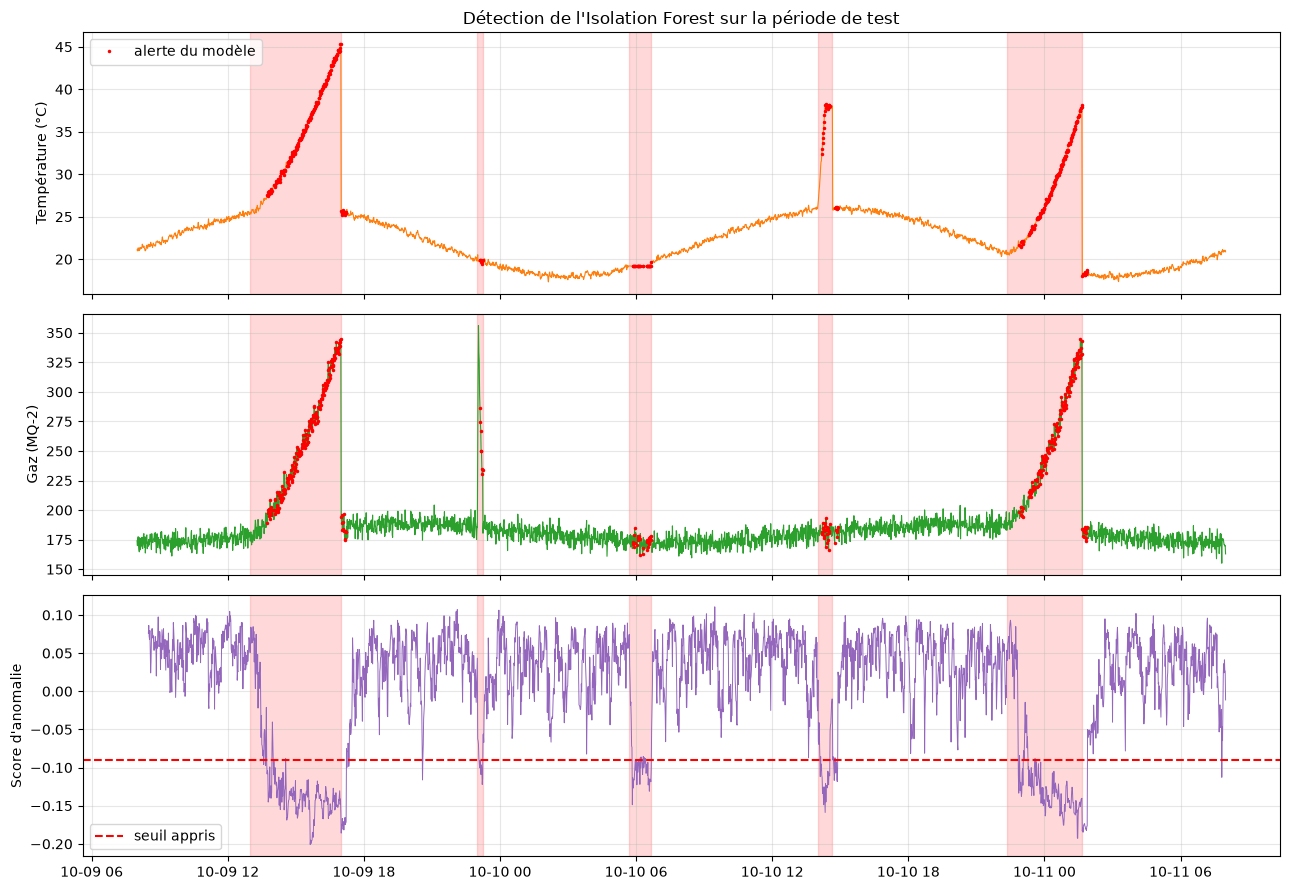

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(test.index, test["temperature"], lw=0.8, color="tab:orange")
axes[0].plot(alerte_test[alerte_test].index, test.loc[alerte_test[alerte_test].index, "temperature"],
             "r.", ms=3, label="alerte du modèle")
shade_events(axes[0], test); axes[0].set_ylabel("Température (°C)"); axes[0].legend(loc="upper left")

axes[1].plot(test.index, test["gas"], lw=0.8, color="tab:green")
axes[1].plot(alerte_test[alerte_test].index, test.loc[alerte_test[alerte_test].index, "gas"], "r.", ms=3)
shade_events(axes[1], test); axes[1].set_ylabel("Gaz (MQ-2)")

axes[2].plot(scores_test.index, scores_test, lw=0.7, color="tab:purple")
axes[2].axhline(seuil, color="red", ls="--", label="seuil appris")
shade_events(axes[2], test); axes[2].set_ylabel("Score d'anomalie"); axes[2].legend(loc="lower left")

axes[0].set_title("Détection de l'Isolation Forest sur la période de test")
plt.tight_layout(); plt.show()

## Étape 6 — Évaluation

On évalue à **deux niveaux** :

1. **Au niveau des mesures** : précision / rappel / F1 (chaque minute compte comme un exemple) ;
2. **Au niveau des événements** (plus parlant) : chaque panne est-elle détectée ? Avec quel **délai** ? Et surtout : pour les dérives lentes, l'alerte arrive-t-elle **avant** un seuil critique classique ?

Pour comparer, on calcule la date à laquelle un seuil fixe (`température > 38 °C`) aurait déclenché. **Ce seuil sert uniquement de point de comparaison** pour mesurer notre avance — il n'est pas utilisé par le modèle.

In [19]:
# Evaluation des mesures
def metriques_mesures(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {"precision": p, "rappel": r, "F1": f1, "TP": tp, "FP": fp, "FN": fn, "TN": tn}

m = metriques_mesures(y_test, alerte_test.astype(int))
pd.Series(m).round(3).to_frame("Isolation Forest")

,Isolation Forest
precision,0.917
rappel,0.701
F1,0.795
TP,389.000
FP,35.000
FN,166.000
TN,2260.000


In [20]:
SEUIL_CRITIQUE_TEMP = 38   # °C — uniquement pour mesurer l'avance du modèle

def evaluer_evenements(df, alerte):
    """Un tableau avec, pour chaque panne : détectée ? après combien de minutes ? avance sur le seuil fixe ?"""
    lab = df.loc[alerte.index, "event"]
    run = (lab != lab.shift()).cumsum()
    lignes = []
    for _, g in lab[lab != "normal"].groupby(run[lab != "normal"]):
        debut, fin = g.index[0], g.index[-1]
        al = alerte.loc[debut:fin]
        premiere = al[al].index[0] if al.any() else None
        detectee = premiere is not None
        delai = (premiere - debut).total_seconds() / 60 if detectee else np.nan

        # Quand le seuil fixe aurait-il réagi ?
        depasse = df.loc[debut:fin]
        depasse = depasse[depasse["temperature"] > SEUIL_CRITIQUE_TEMP]
        t_fixe = depasse.index[0] if len(depasse) else None
        avance = (t_fixe - premiere).total_seconds() / 60 if (detectee and t_fixe is not None) else np.nan

        lignes.append({
            "événement": g.iloc[0], "début": debut.strftime("%d/%m %H:%M"),
            "durée (min)": len(g), "détectée": detectee,
            "délai de détection (min)": delai,
            "avance sur seuil 38°C (min)": avance,
        })
    return pd.DataFrame(lignes)

res = evaluer_evenements(test, alerte_test)
res

,événement,début,durée (min),détectée,délai de détection (min),avance sur seuil 38°C (min)
0,derive_lente,09/10 13:00,240,True,45.0,126.0
1,pic_gaz,09/10 23:00,15,True,7.0,NaN
2,capteur_fige,10/10 05:40,60,True,12.0,NaN
3,surchauffe,10/10 14:00,40,True,11.0,9.0
4,derive_lente,10/10 22:20,200,True,33.0,166.0


In [21]:
normal_mask = (y_test == 0)
fausses_alertes = int(alerte_test[normal_mask].sum())
print(f"Fausses alertes (mesures normales marquées en alerte) : {fausses_alertes} "
      f"sur {int(normal_mask.sum())} mesures normales ({fausses_alertes / normal_mask.sum():.2%})")
print(f"Événements détectés : {int(res['détectée'].sum())}/{len(res)}")

# Ces « fausses alertes » sont-elles vraiment spontanées ? Beaucoup viennent de l'effet de queue des
# fenêtres glissantes : juste après la fin d'une panne, les features « se souviennent » encore d'elle.
apres_panne = y_test.rolling(2 * W_LONG, min_periods=1).max().astype(bool)   # panne en cours ou < 60 min avant
fa_queue = int(alerte_test[normal_mask & apres_panne].sum())
fa_vraies = int(alerte_test[normal_mask & ~apres_panne].sum())
print(f"  dont effet de queue juste après une panne : {fa_queue}")
print(f"  dont fausses alertes « spontanées »        : {fa_vraies}")

Fausses alertes (mesures normales marquées en alerte) : 35 sur 2295 mesures normales (1.53%)
Événements détectés : 5/5
  dont effet de queue juste après une panne : 35
  dont fausses alertes « spontanées »        : 0


**Comment lire ces résultats ?**
- **Délai de détection** : minutes écoulées entre le début réel de la panne et la première alerte (plus c'est petit, mieux c'est).
- **Avance sur seuil fixe** : pour les dérives lentes, combien de minutes *avant* le dépassement de 38 °C le modèle a prévenu. C'est la **valeur ajoutée** de la maintenance prédictive face à un simple `if`.
- Une partie des « fausses alertes » est un **effet de queue** : juste après la fin d'une panne, les fenêtres glissantes contiennent encore des mesures anormales, donc l'alerte persiste quelques minutes. C'est cohérent (le système n'est pas encore « revenu à la normale »), mais à connaître pour la démo.
- Le **rappel au niveau des mesures** est naturellement < 100 % : le début d'une dérive lente ressemble encore au normal, c'est attendu. Ce qui compte, c'est que l'événement soit repéré **tôt**.

### Expérience à faire
Change `QUANTILE_SEUIL` (étape 5) : `0.001` → moins de fausses alertes mais détection plus tardive ; `0.02` → détection plus précoce mais plus de fausses alertes. C'est le **compromis précision / rappel** à régler pour la vraie démo.

In [23]:
# 1) Sauvegarde du modèle + de sa configuration
joblib.dump({
    "model": iso, "seuil": float(seuil), "features": list(X_train.columns),
    "W": W, "W_LONG": W_LONG, "persistance": PERSISTANCE,
}, "sentinel_isolation_forest.joblib")
print("Modèle sauvegardé : sentinel_isolation_forest.joblib")

# 2) Détecteur temps réel
class DetecteurTempsReel:
    def __init__(self, bundle, device_id="esp8266-01"):
        self.model = bundle["model"]
        self.seuil = bundle["seuil"]
        self.cols = bundle["features"]
        self.persistance = bundle["persistance"]
        self.device_id = device_id
        self.buffer = deque(maxlen=bundle["W_LONG"] + 1)       # juste assez d'historique
        self.derniers = deque(maxlen=self.persistance)

    def update(self, mesure: dict):
        """mesure = {"timestamp", "temperature", "humidity", "gas", ...}. Retourne un payload d'alerte ou None."""
        self.buffer.append(mesure)
        if len(self.buffer) < self.buffer.maxlen:
            return None                                          # pas encore assez d'historique

        fenetre = pd.DataFrame(self.buffer).set_index("timestamp")
        feats = make_features(fenetre)[self.cols].iloc[[-1]]     # features de la mesure courante
        score = float(self.model.decision_function(feats)[0])
        self.derniers.append(score < self.seuil)

        if len(self.derniers) == self.persistance and all(self.derniers):
            return {                                             # format à valider avec l'équipe DEV
                "device_id": self.device_id,
                "type": "predictive_anomaly",
                "severity": "critical" if score < self.seuil * 2 else "warning",
                "score": round(score, 4),
                "timestamp": mesure["timestamp"].isoformat(),
                "measures": {k: round(float(mesure[k]), 2) for k in ("temperature", "humidity", "gas")},
            }
        return None

bundle = joblib.load("sentinel_isolation_forest.joblib")
detecteur = DetecteurTempsReel(bundle)

Modèle sauvegardé : sentinel_isolation_forest.joblib


In [24]:
# Rejouons la 1re dérive lente comme si les mesures arrivaient une par une
debut_derive = test.index[300]
flux = test.loc[debut_derive - pd.Timedelta(minutes=60): debut_derive + pd.Timedelta(minutes=240)]

premiere_alerte = None
for ts, row in flux.iterrows():
    mesure = {"timestamp": ts, "temperature": row["temperature"], "humidity": row["humidity"],
              "gas": row["gas"], "pir": row["pir"]}
    alerte = detecteur.update(mesure)
    if alerte:
        premiere_alerte = alerte
        break

print("Début réel de la dérive :", debut_derive)
print("Payload qui serait envoyé à POST /api/v1/alerts :")
print(json.dumps(premiere_alerte, indent=2, ensure_ascii=False))

Début réel de la dérive : 2026-10-09 13:00:00
Payload qui serait envoyé à POST /api/v1/alerts :
{
  "device_id": "esp8266-01",
  "type": "predictive_anomaly",
  "severity": "warning",
  "score": -0.0775,
  "timestamp": "2026-10-09T13:32:00",
  "measures": {
    "temperature": 26.53,
    "humidity": 53.86,
    "gas": 185.72
  }
}
